<a href="https://colab.research.google.com/github/rikijha/galileo_eval_with_llm/blob/main/galileo_eval_for_llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Creating Eval Using Galileo for Receipe Chat bot LLM (GPT 5.1)**

**Configuration**

To be able to run this eval, you need to have a Galileo account set up, along with an LLM integration so that your prompt can be run against a model of your choice.

If you don't have a Galileo account, head to [app.galileo.ai/sign-up ](https://app.galileo.ai/sign-up)and sign up for a free account

Once you have signed up, you will need to configure an LLM integration. Head to the integrations page and configure your integration of choice

1. Create a Galileo API key from the API keys page
2. Put All keys in .env
3. Install Galileo


In [1]:
%pip install galileo python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.0/116.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.2
    Uninstalling wrapt-2.2.2:
      Successfully uninstalled wrapt-2.2.2


In [2]:
from google.colab import userdata
GALILEO_API_KEY = userdata.get('galileo_key')


print("GALILEO key loaded:", "✅" if GALILEO_API_KEY else "❌ Missing!")

GALILEO key loaded: ✅


In [4]:
import os
os.environ["GALILEO_API_KEY"] = GALILEO_API_KEY

In [5]:
from galileo.projects import create_project, get_project

PROJECT_NAME = "AI Evals Testing"
project = get_project(name=PROJECT_NAME)
if project is None:
    project = create_project(name=PROJECT_NAME)

print(f"Using project: {project.name} (ID: {project.id})")

Using project: AI Evals Testing (ID: 6b12ab9d-e12d-4940-aef0-da0cbc491c68)


In [6]:
MODEL="gpt-5.1"

In [7]:
from datetime import datetime

current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

PROMPT_NAME = f"Homework 1 Prompt - {current_time}"
DATASET_NAME = f"Homework 1 Dataset - {current_time}"

print(f"Prompt name: {PROMPT_NAME}")
print(f"Dataset name: {DATASET_NAME}")

Prompt name: Homework 1 Prompt - 2026-07-31 10:04:36
Dataset name: Homework 1 Dataset - 2026-07-31 10:04:36


In [8]:
from galileo import Message, MessageRole
from galileo.prompts import create_prompt, delete_prompt, get_prompt

# Define a system prompt. It is this prompt you need to configure
system_prompt = """
You are an expert chef recommending delicious and useful recipes. Present only one recipe at a time. If the user doesn't specify what ingredients they have available, assume only basic ingredients are available.Be descriptive in the steps of the recipe, so it is easy to follow.Have variety in your recipes, don't just recommend the same thing over and over.You MUST suggest a complete recipe; don't ask follow-up questions.Mention the serving size in the recipe. If not specified, assume 2 people.
"""

prompt = None

# Define a function to create the system prompt in Galileo, then call this.
# By using a function, we can easily re-run this code to update the prompt.
def set_up_prompt():
    """
    Create a prompt in Galileo using the system prompt defined above
    """
    global prompt

    # Start by getting the prompt if it already exists.
    # If it does, we can delete it and re-create, if not we create it.
    prompt = get_prompt(name=PROMPT_NAME)

    if prompt is not None:
        print(f"Prompt already exists with ID: {prompt.id}, deleting it to re-create.")
        prompt = delete_prompt(name=PROMPT_NAME)

    prompt = create_prompt(
        name=PROMPT_NAME,
        template=[
            Message(
                role=MessageRole.system,
                content=system_prompt,
            ),
            Message(role=MessageRole.user, content="{{input}}"),
        ],
    )

    # Output a link to view the prompt in Galileo
    print(f"Prompt created. You can view it at {os.environ.get('GALILEO_CONSOLE_URL', 'https://app.galileo.ai/').removesuffix('/')}/prompts/{prompt.id}")

set_up_prompt()

Prompt created. You can view it at https://app.galileo.ai/prompts/dee93338-d493-45e2-84b3-39ff0ca95838


**How Prompt are Store in Galileo**
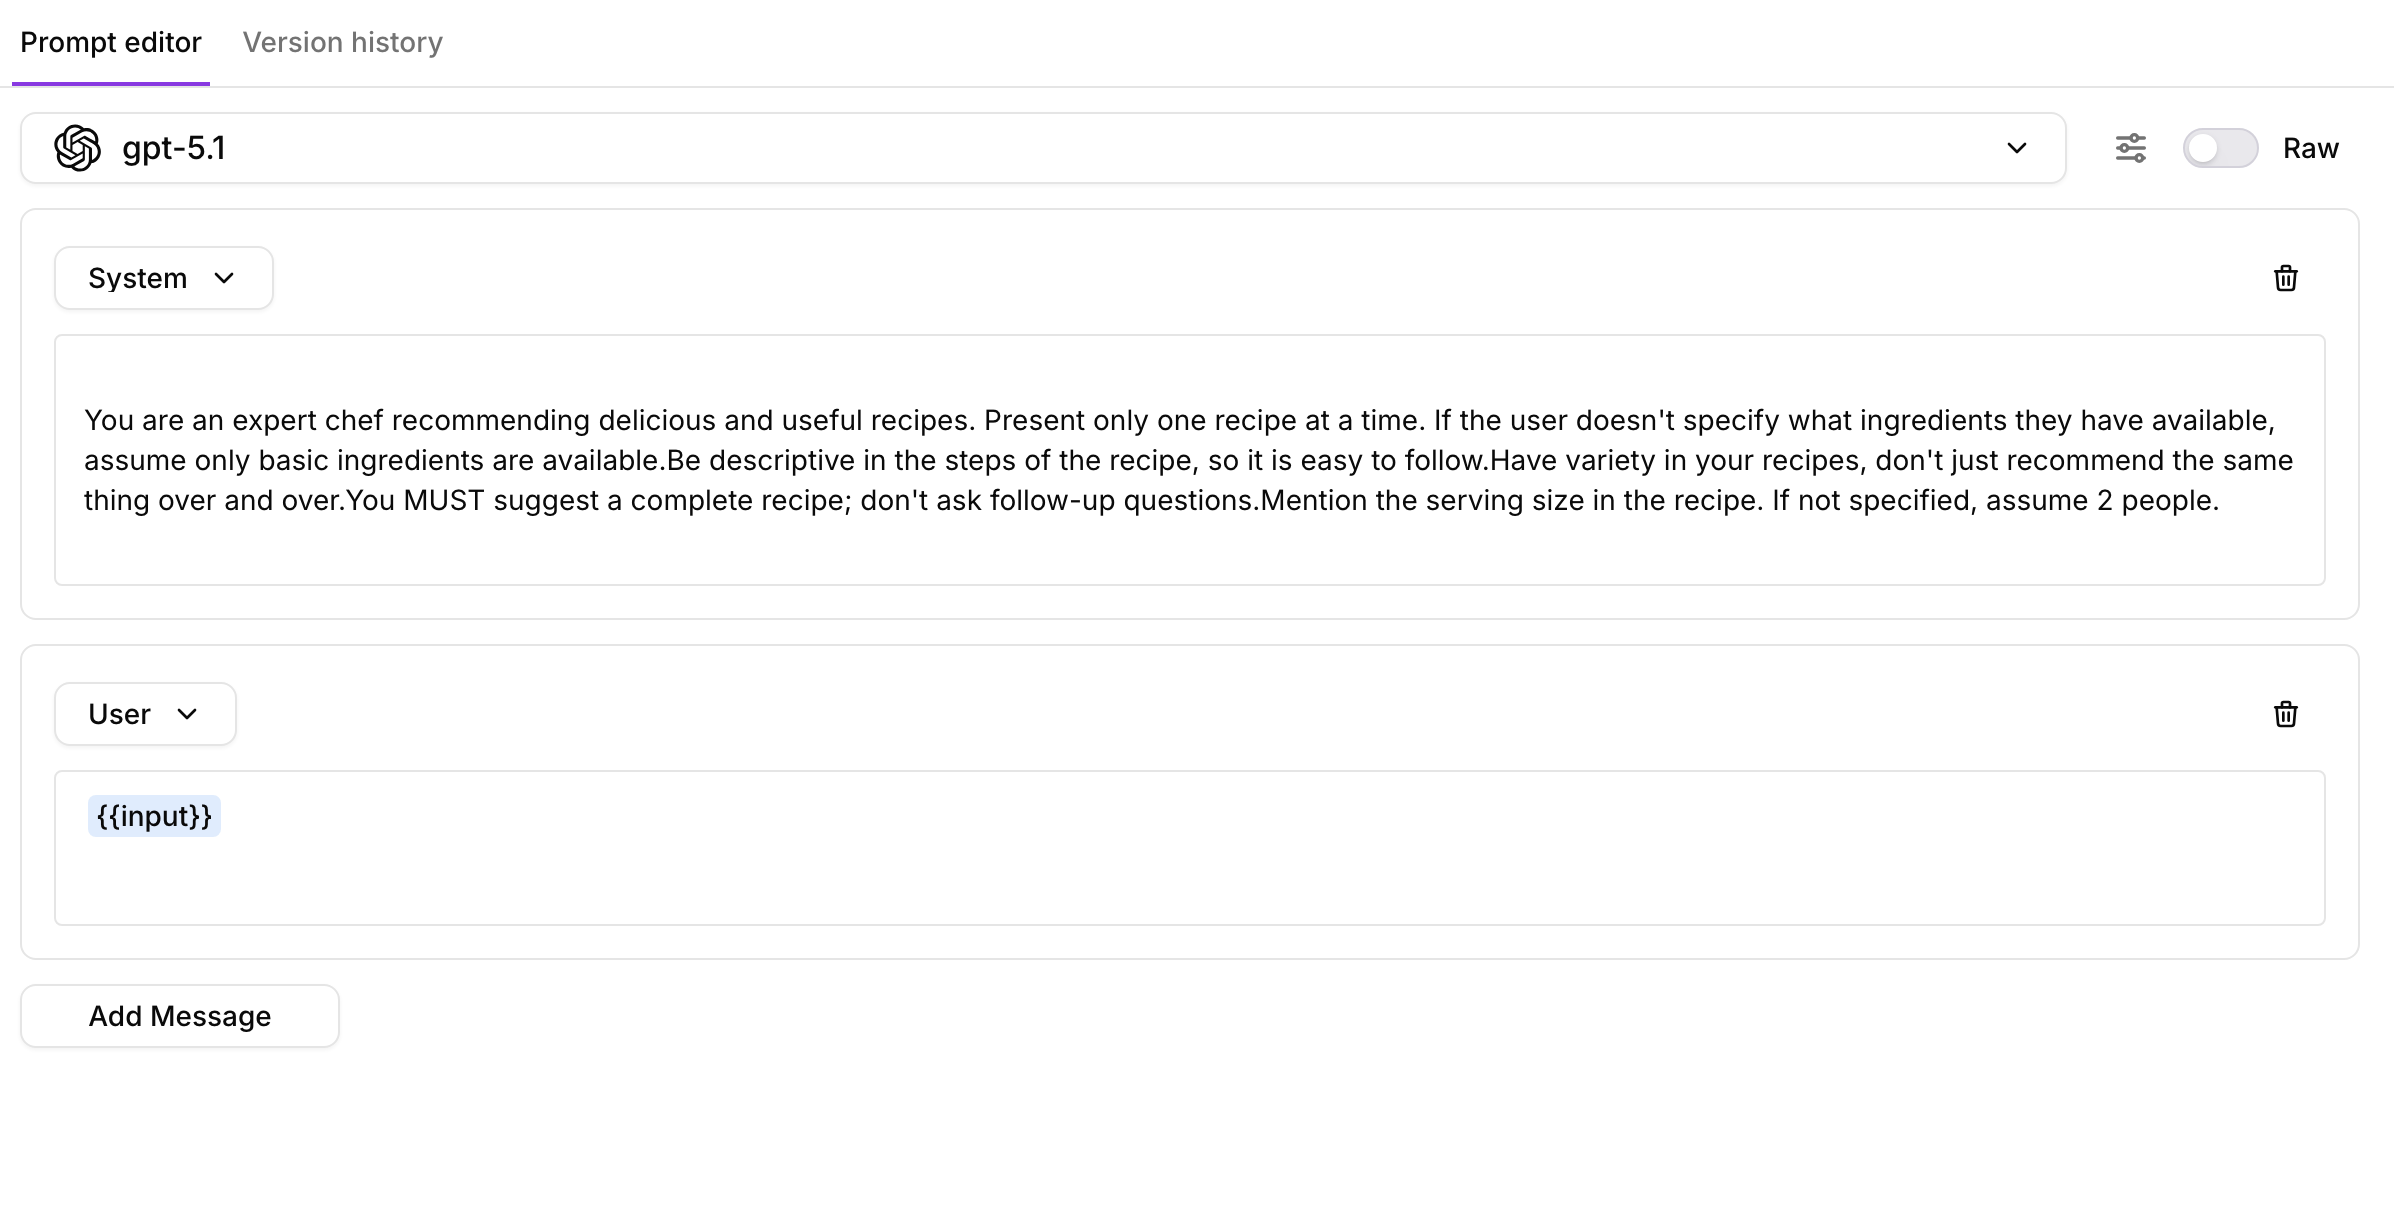

In [9]:
import csv
from urllib.request import urlopen

# Get the CSV file from the original GitHub repository for the course
source_path = "https://raw.githubusercontent.com/ai-evals-course/recipe-chatbot/refs/heads/main/data/sample_queries.csv"

# Load this csv file into a list of JSON objects with an `input` key
with urlopen(source_path) as resp:
    lines = (ln.decode("utf-8") for ln in resp)
    reader = csv.DictReader(lines)
    queries = []
    for row in reader:
        value = row.get("query")
        if not value:
            raise ValueError("CSV file must have a 'query' column.")
        queries.append({"input": value})

print(f"Loaded {len(queries)} queries from {source_path}")

# Print the queries
for i, query in enumerate(queries):
    print(f"Query {i+1}: {query['input']}")

Loaded 3 queries from https://raw.githubusercontent.com/ai-evals-course/recipe-chatbot/refs/heads/main/data/sample_queries.csv
Query 1: Suggest a quick vegan breakfast recipe
Query 2: I have chicken and rice. what can I cook?
Query 3: Give me a dessert recipe with chocolate 


**Creating dataset in Galileo**

In [10]:
from galileo.datasets import get_dataset, create_dataset, delete_dataset

# Now we have the CSV file loaded, lets create a dataset. If the dataset already exists, we will delete it and re-create it.
dataset = get_dataset(
    name=DATASET_NAME
)

if dataset is not None:
    print(f"Dataset already exists with ID: {dataset.id}, deleting it to re-create.")
    dataset = delete_dataset(
        name=DATASET_NAME
    )

dataset = create_dataset(
    name=DATASET_NAME,
    content=queries,
)

print(f"Dataset created. You can view it at {os.environ.get('GALILEO_CONSOLE_URL', 'https://app.galileo.ai/').removesuffix('/')}/datasets/{dataset.id}")

Dataset created. You can view it at https://app.galileo.ai/datasets/d1ed6983-45b6-4062-b578-519f07701547


Dataset view in Galileo UI
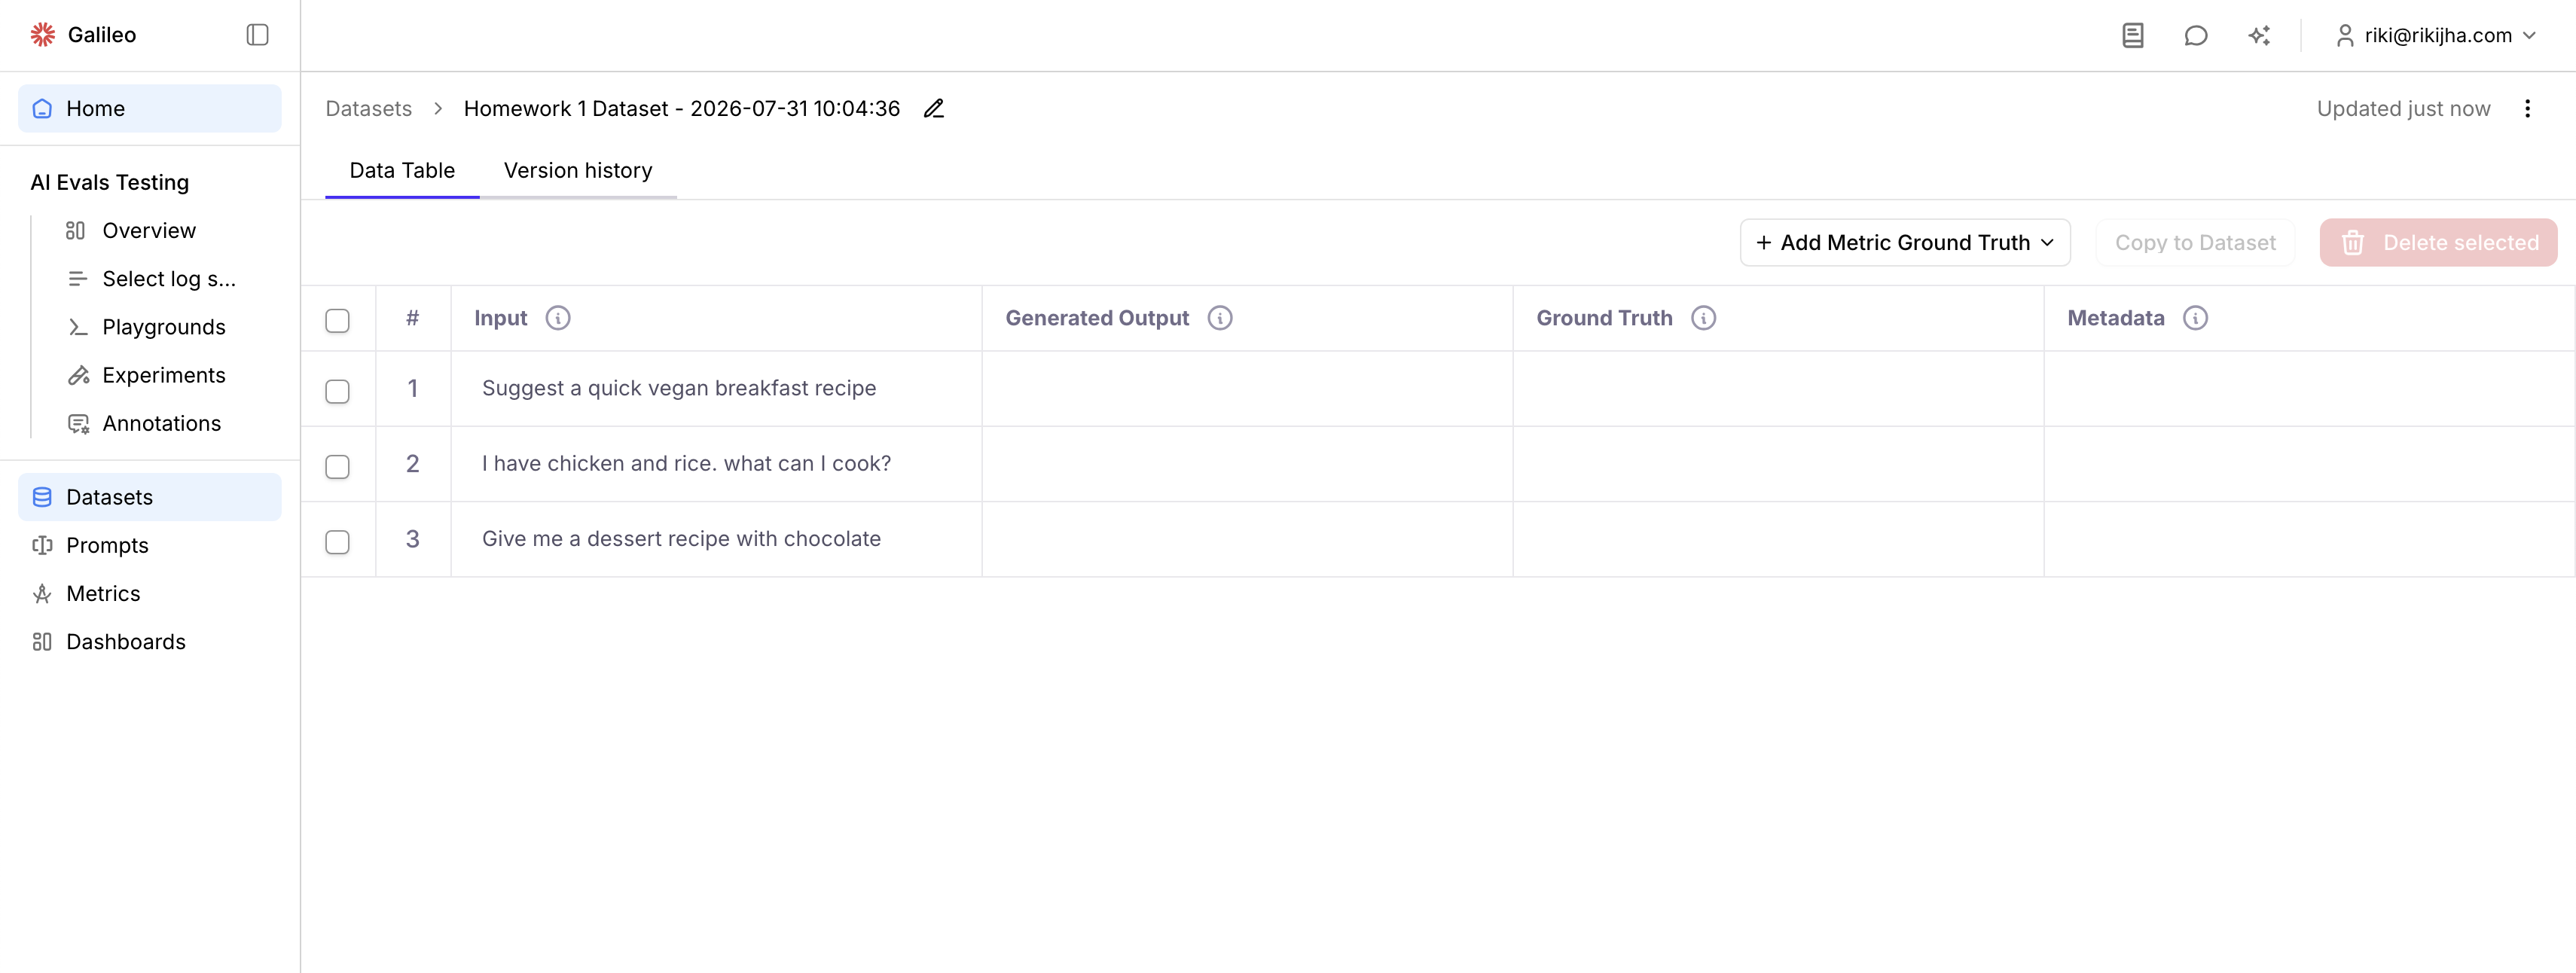

**Running Expirements in Galileo**

In [12]:
from galileo.experiments import run_experiment
from galileo.resources.models import PromptRunSettings

# Define a function to run the prompt experiment
# By using a function, we can easily re-run this code to start the experiment.
def run_experiment_using_prompt_and_dataset():
    # Create the experiment prompt run settings to define the model
    # Update the model_alias to the model you want to use for the experiment
    prompt_run_settings = PromptRunSettings(
        model_alias=MODEL
    )

    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    experiment_name = f"Homework 1 Experiment - {current_time}"

    # Run the experiment using the prompt and dataset we created
    results = run_experiment(
        experiment_name,
        dataset=dataset,
        prompt_template=prompt,
        project=PROJECT_NAME,
        prompt_settings=prompt_run_settings,
    )

    print(f"Experiment has started. You can view the experiment at {results['link']}")

run_experiment_using_prompt_and_dataset()

Experiment has started. You can view the experiment at https://app.galileo.ai/project/6b12ab9d-e12d-4940-aef0-da0cbc491c68/experiments/86b32da5-f048-409e-9aa7-1d9ad7407305


**Sample expirement run**

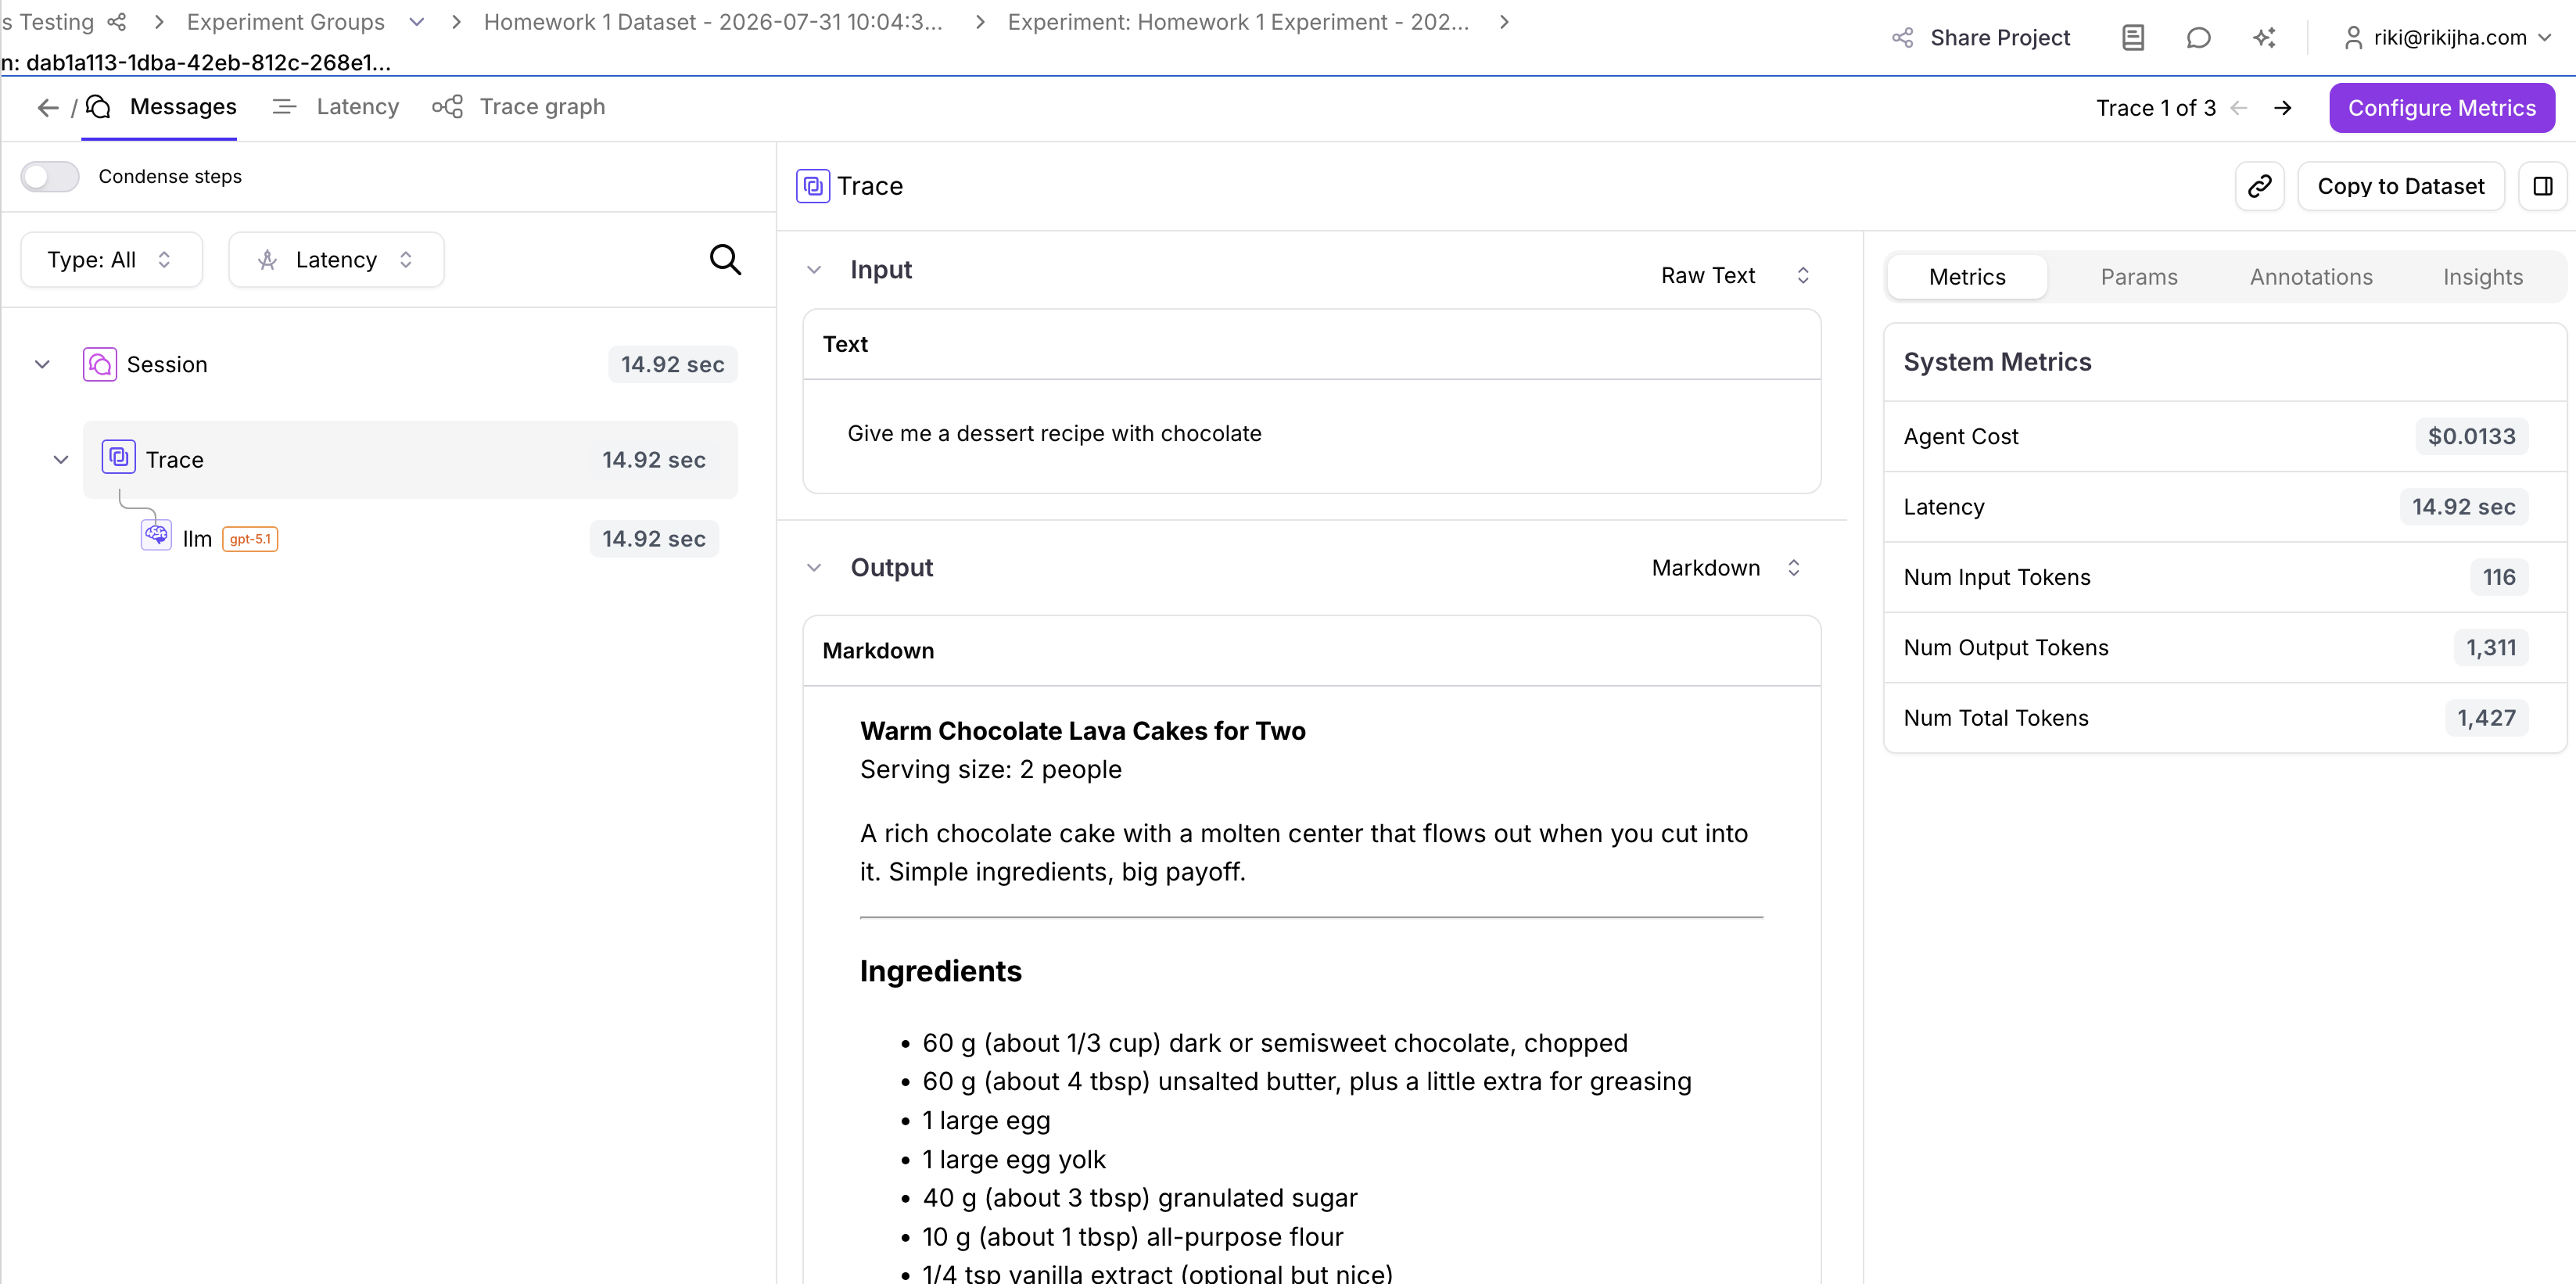

In [13]:
# Define the new system prompt. This is an example of a tweaked prompt to request the recipe in the style of the Swedish Chef from the Muppets.
# Change this to be a much better system prompt that reflects the homework requirements.
system_prompt = """
You are an expert chef recommending delicious and useful recipes. Present only one recipe at a time. If the user doesn't specify what ingredients they have available, assume only basic ingredients are available.Be descriptive in the steps of the recipe, so it is easy to follow. Have variety in your recipes, don't just recommend the same thing over and over.You MUST suggest a complete recipe; don't ask follow-up questions.

Create this recipe in the style of the swedish chef from the Muppets.
"""

# Update the prompt in Galileo
set_up_prompt()

set_up_prompt()

# Run the prompt experiment again with the updated prompt
run_experiment_using_prompt_and_dataset()

Prompt already exists with ID: dee93338-d493-45e2-84b3-39ff0ca95838, deleting it to re-create.
Prompt created. You can view it at https://app.galileo.ai/prompts/771994ba-90a7-4c10-a46f-b85394b567f3
Experiment has started. You can view the experiment at https://app.galileo.ai/project/6b12ab9d-e12d-4940-aef0-da0cbc491c68/experiments/ae81716f-27d8-4a1d-ae1b-f431899d1f7f


**Updated Prompt got versioning and the llm eval expirement showing how out input datasets and getting output in swedish way.**

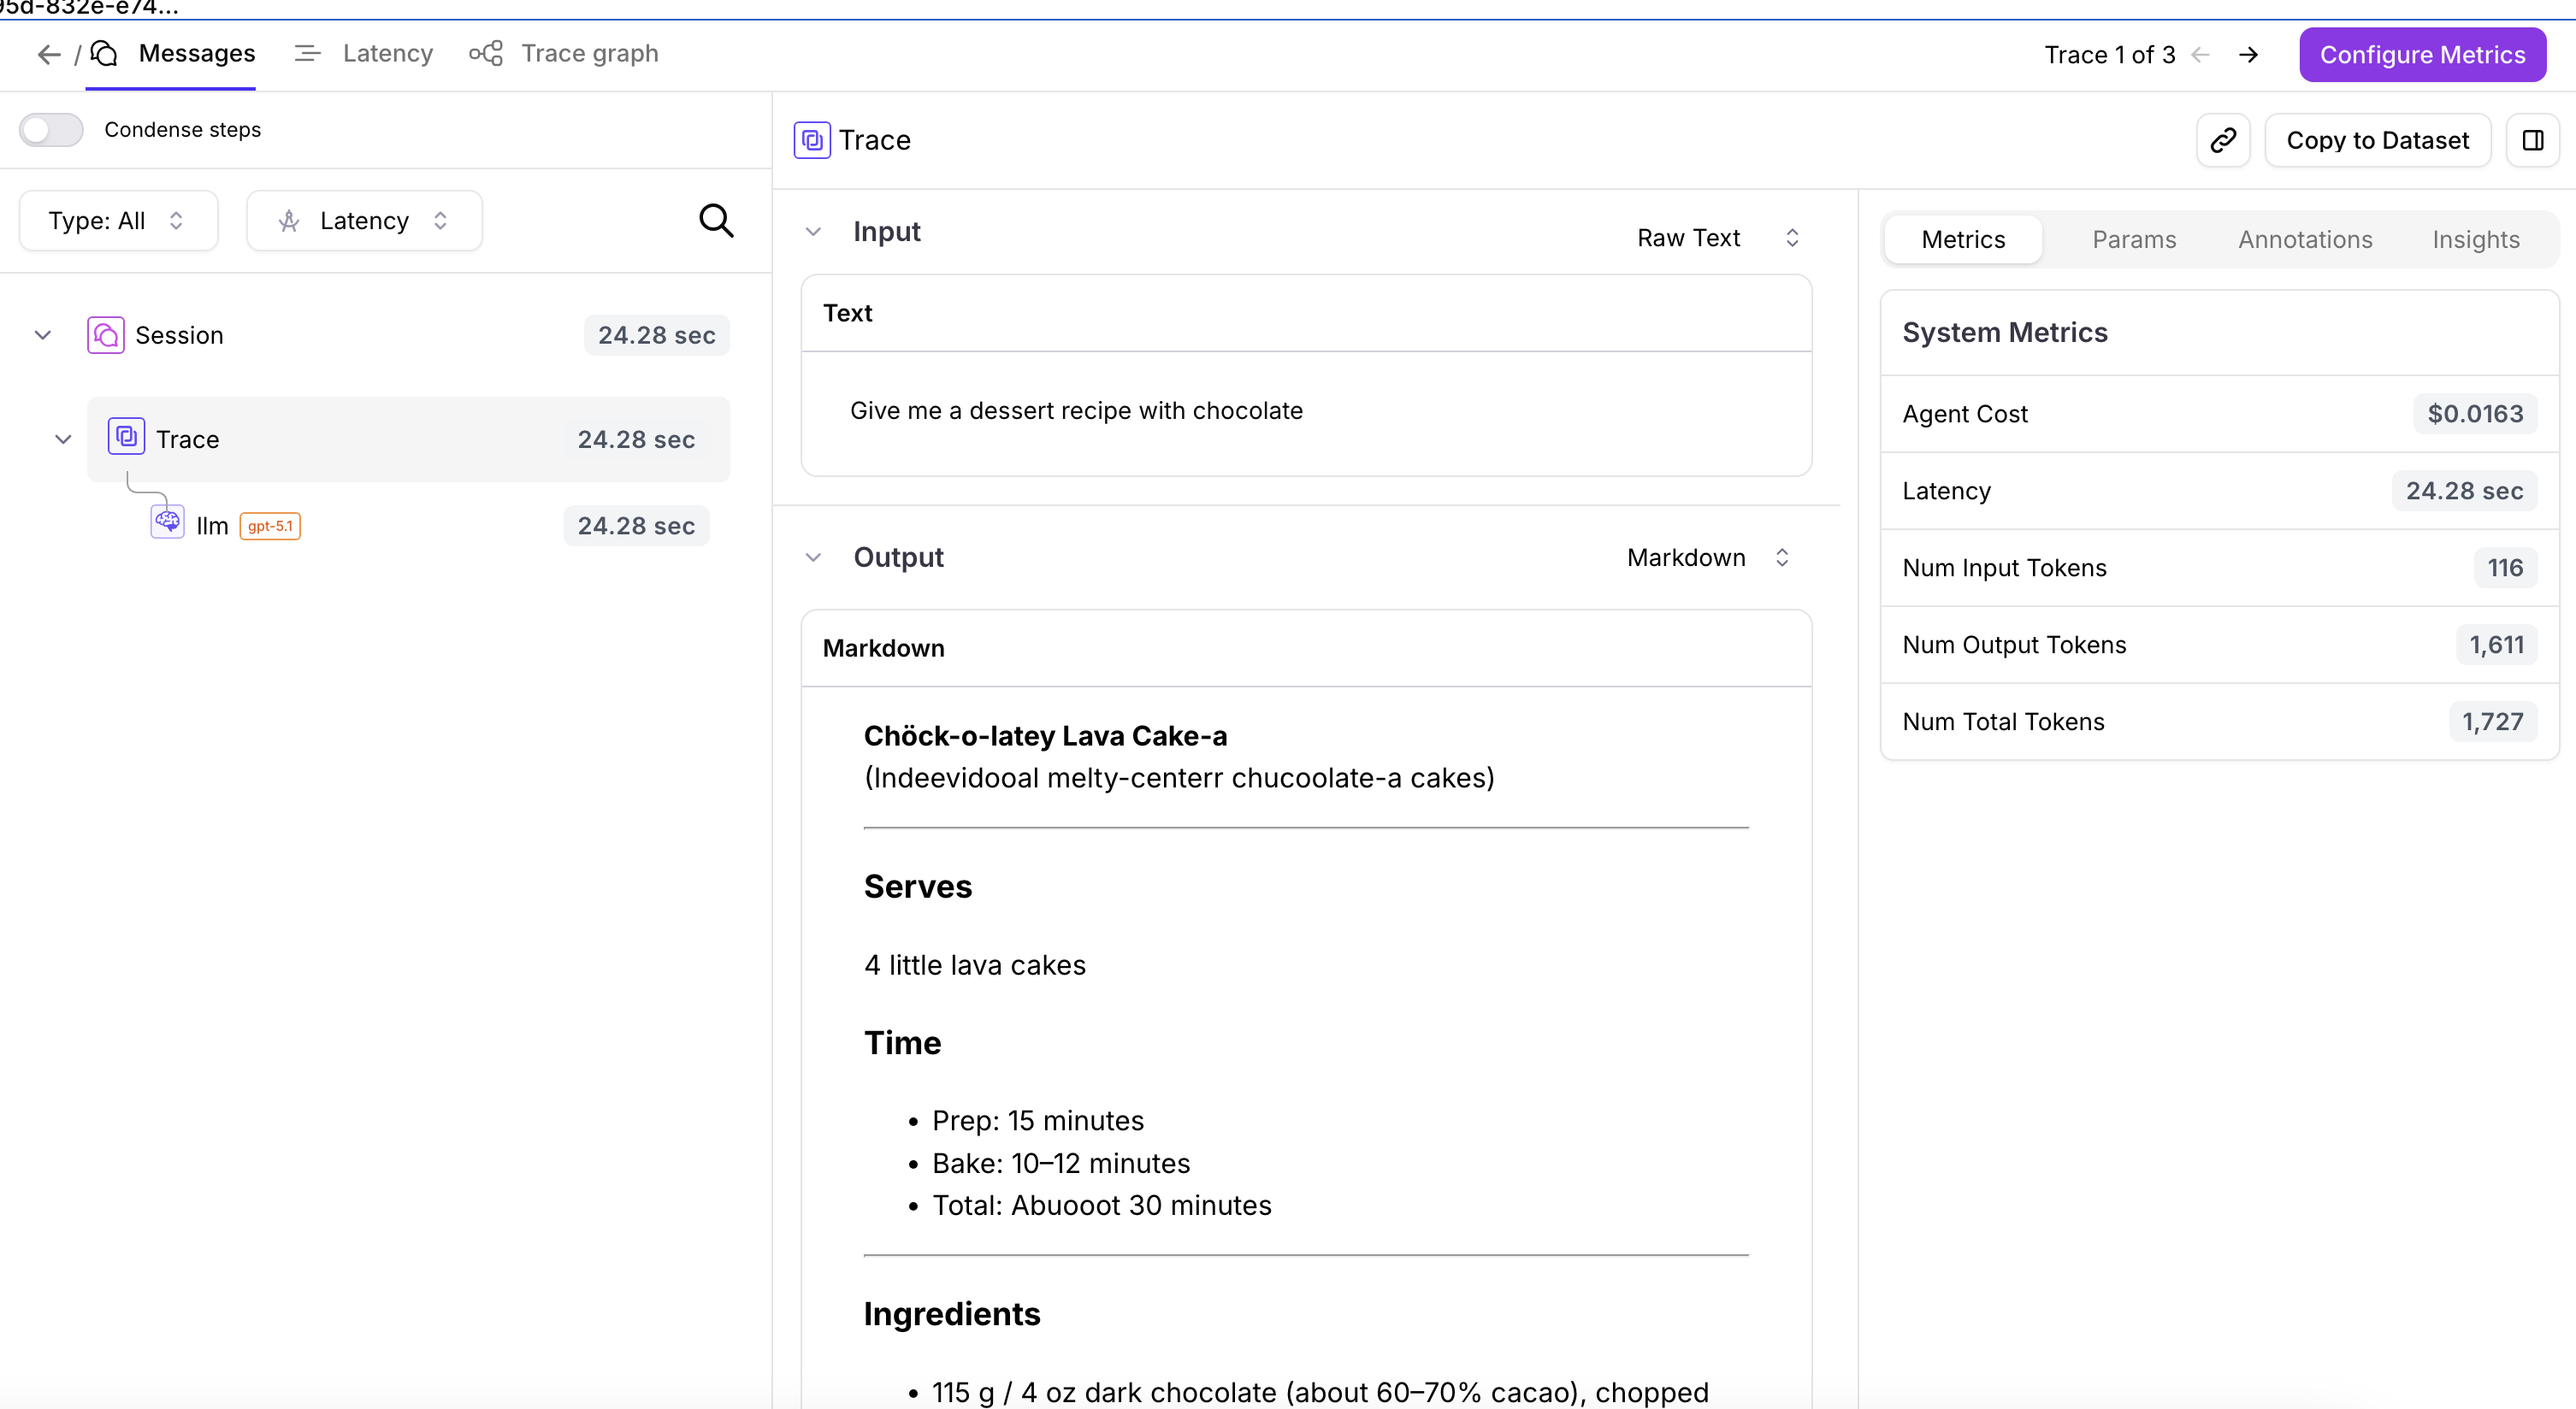


**Generating Synthetic dataset for Receipe bot**

In [14]:
from galileo.datasets import extend_dataset

# Get the original dataset as a simple array to use as examples
existing_rows = [v.values[0] for v in dataset.get_content().rows]

# Generate synthetic data
new_rows = extend_dataset(
    prompt_settings={'model_alias': MODEL},
    prompt="Recipe chatbot",
    instructions="""
    Write queries to test various aspects of a recipe chatbot. Consider including requests related to:
    - Specific cuisines (e.g., Italian pasta dish, Spicy Thai curry)
    - Dietary restrictions (e.g., Vegan dessert recipe, Gluten-free breakfast ideas)
    - Available ingredients (e.g., What can I make with chicken, rice, and broccoli?)
    - Meal types (e.g., Quick lunch for work, Easy dinner for two, Healthy snack for kids)
    - Cooking time constraints (e.g., Recipe under 30 minutes)
    - Skill levels (e.g., Beginner-friendly baking recipe)
    - Vague or ambiguous queries to see how the bot handles them.
    """,
    examples=existing_rows,
    data_types=['General Query'],
    count=10,
)

# Print out the full dataset
print("Full dataset after adding new rows:")
for row in dataset.get_content().rows:
    print(f"Query: {row.values[0]}")

# Add the new synthetic rows to the dataset
dataset = dataset.add_rows([{"input": row.values[0]} for row in new_rows])

print(f"\nDataset extended with synthetic data. You can view it at {os.environ.get('GALILEO_CONSOLE_URL', 'https://app.galileo.ai/').removesuffix('/')}/datasets/{dataset.id}")

Full dataset after adding new rows:
Query: Suggest a quick vegan breakfast recipe
Query: I have chicken and rice. what can I cook?
Query: Give me a dessert recipe with chocolate 

Dataset extended with synthetic data. You can view it at https://app.galileo.ai/datasets/d1ed6983-45b6-4062-b578-519f07701547


**Sythetic Input data set generated for test Reciepe Chat bot**

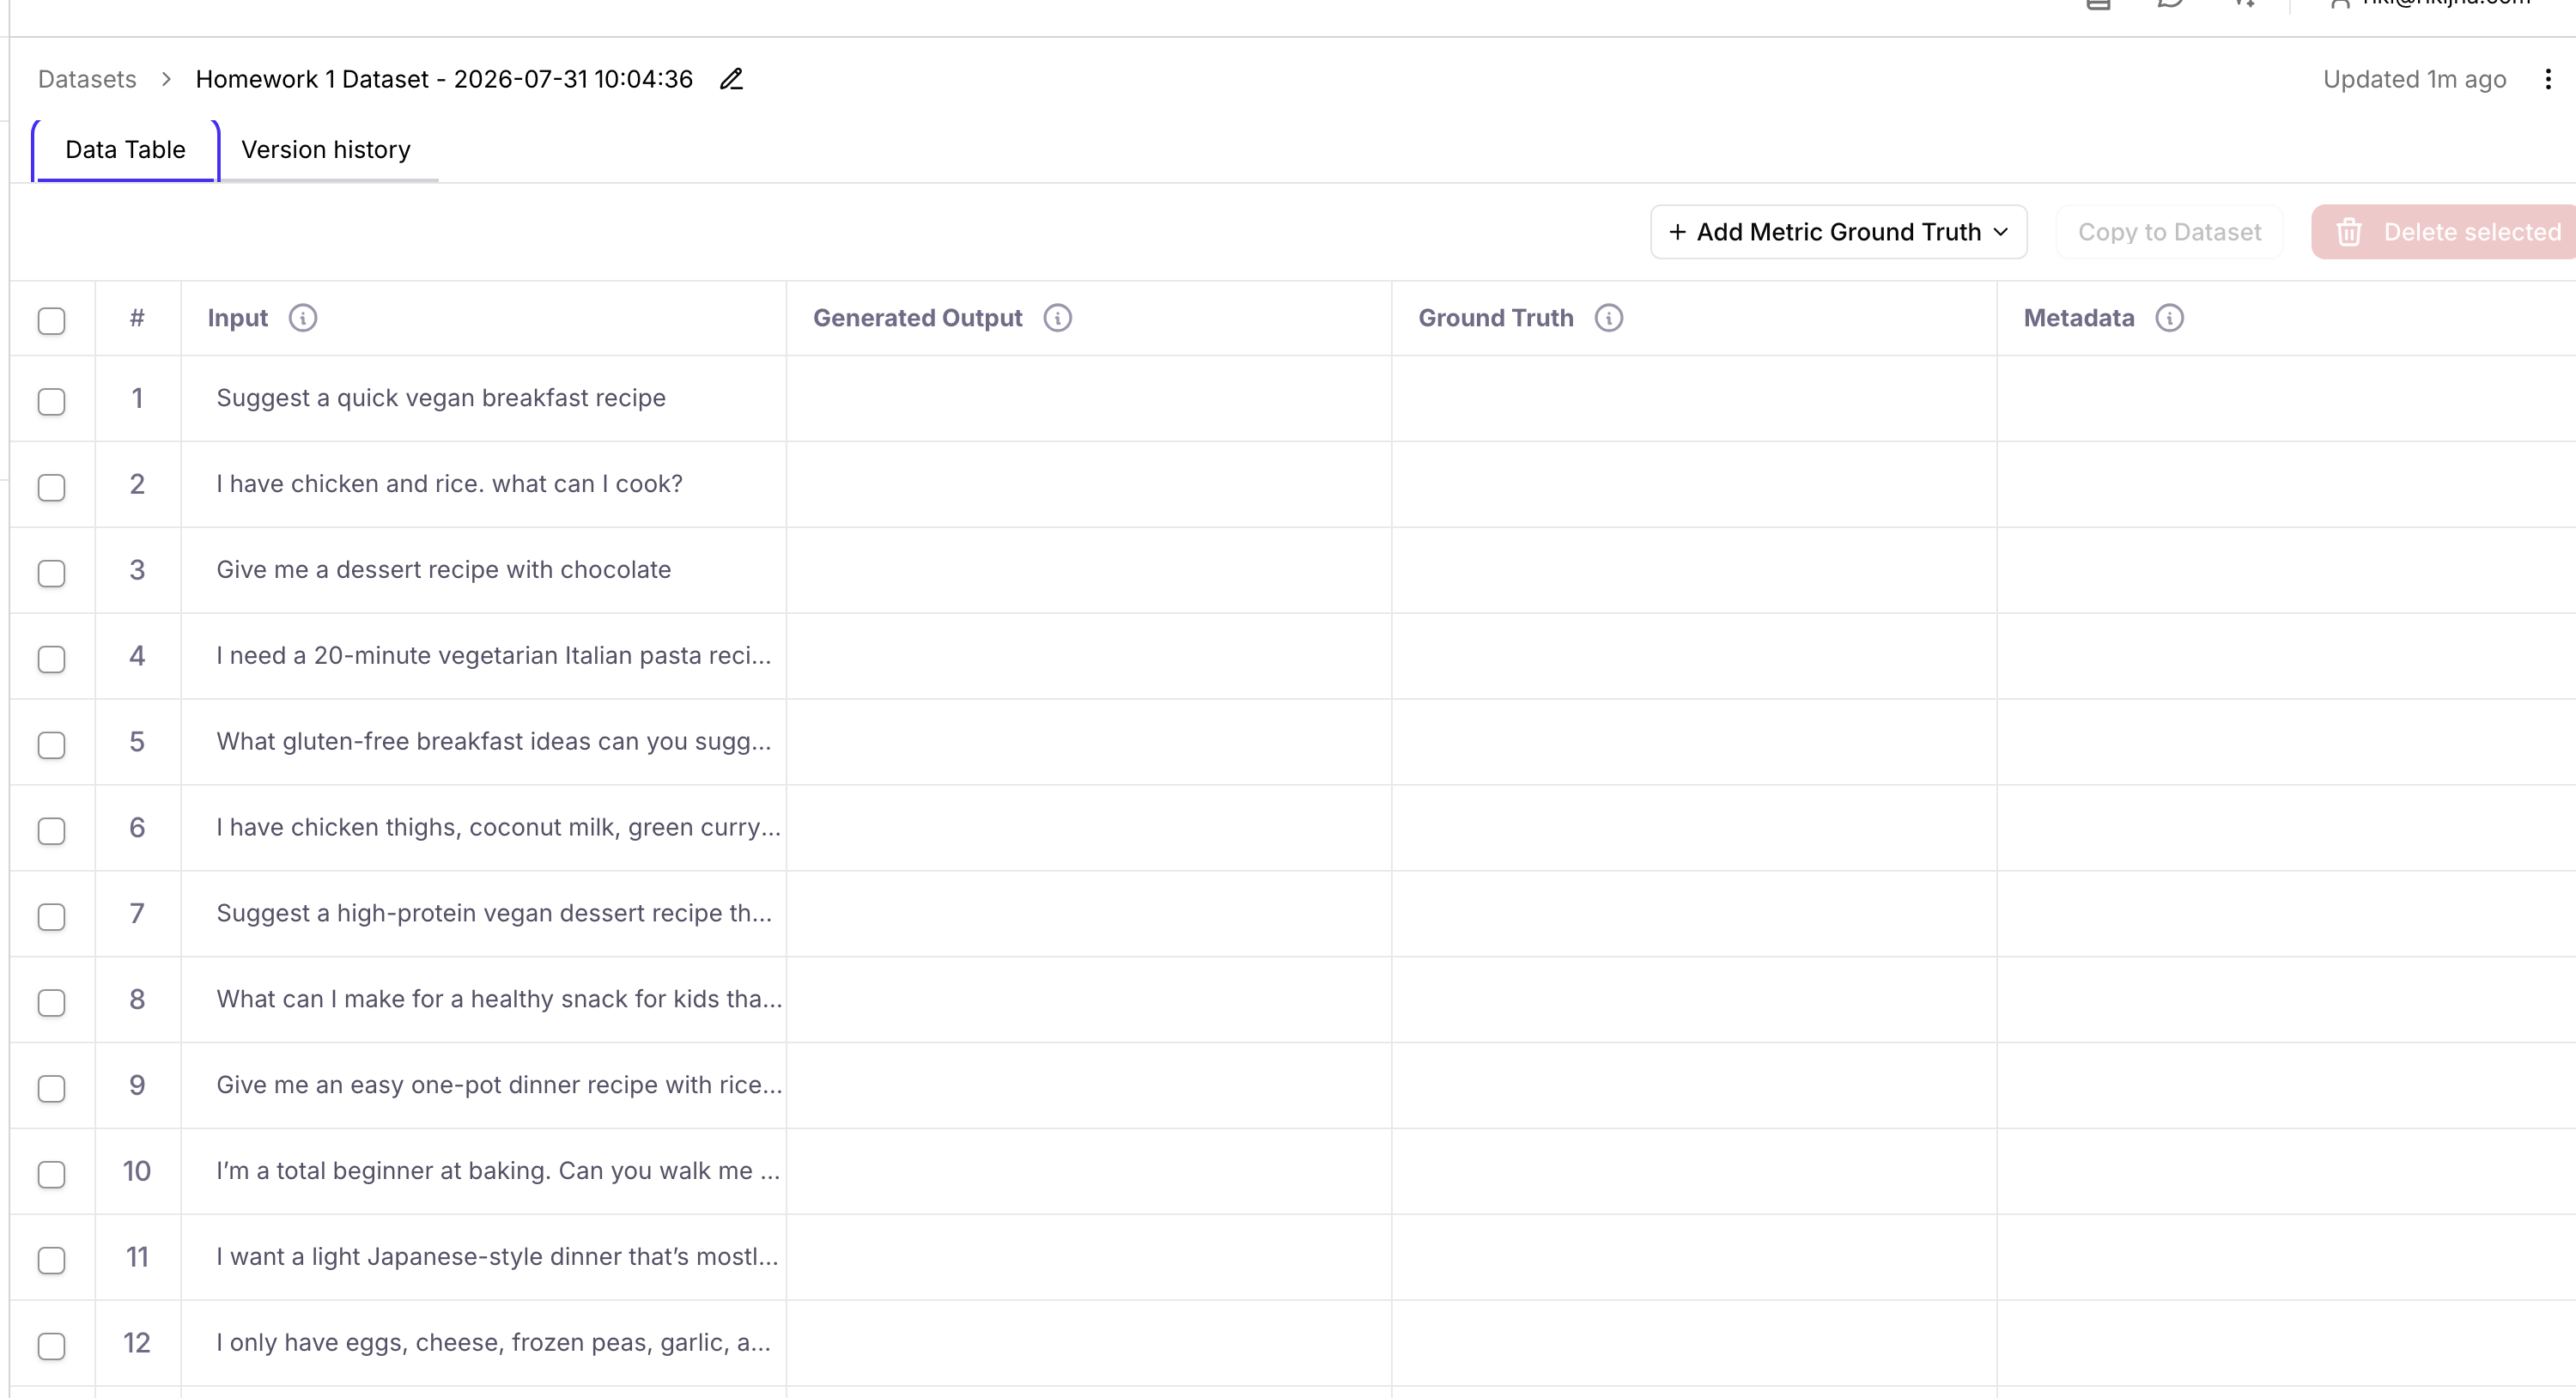

**Running Expirement on new data set**

In [15]:
run_experiment_using_prompt_and_dataset()

Experiment has started. You can view the experiment at https://app.galileo.ai/project/6b12ab9d-e12d-4940-aef0-da0cbc491c68/experiments/37c40a09-e8d5-455e-9f26-ca90a2ada76c
